# Tägliche Produkt-Filial-Abverkaufsreihen mit ADI und CV^2

## Verwendete Schwellenwerte

- **Vorgelagerter Mindestnachfragefilter:** FCM-Produkt-Filial-Reihen benötigen mindestens 30 aktive Tage und 10 positive Abverkaufstage; Pseudo-Reihen mindestens 120 aktive Tage und 30 positive Abverkaufstage.
- **Notebook-interne Mindestmenge:** Für die ADI/CV²-Auswertung werden nur Reihen mit mindestens 10 positiven Abverkaufstagen verwendet.
- **ADI-Grenze:** 1,32. `ADI < 1,32` bedeutet regelmäßigen, `ADI >= 1,32` seltenen Abverkauf.
- **CV²-Grenze:** 0,49. `CV² < 0,49` bedeutet stabilere, `CV² >= 0,49` variablere positive Mengen.
- **Klassifikation:** smooth `<1,32/<0,49`; erratic `<1,32/>=0,49`; intermittent `>=1,32/<0,49`; lumpy `>=1,32/>=0,49`.
- **Beispielauswahl:** 120 aktive Tage sind nur ein bevorzugtes Kriterium für die vier dargestellten Beispielreihen; falls nötig, fällt die Auswahl auf kürzere Reihen zurück. Dies ist kein Filter für die Gesamtanalyse.
- **FCM–Pseudo-Vergleich:** Es wird kein zusätzlicher Signifikanz- oder Effektstärkeschwellenwert zum Filtern verwendet; Chi-Quadrat, Cramérs V und Residuen werden deskriptiv berichtet.

Dieses Notebook klassifiziert tägliche Produkt-Filial-Abverkaufsreihen in **smooth**, **erratic**, **intermittent** und **lumpy**.

Die Analyse verwendet ausschließlich die regulären verarbeiteten Tagesdaten.


Diese Setup-Zelle importiert die benötigten Bibliotheken, definiert die Produkt-Filial-Ebene, setzt die Spalte für den Abverkauf und die ADI/CV2-Grenzwerte und lädt den verarbeiteten Tagesdatensatz.


In [1]:
from pathlib import Path
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import duckdb
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

GROUP_COLS = ["ARTIKEL_ID", "MARKT_ID"]
DEMAND_COL = "ABVERKAUFTE_MENGE_KG"
MIN_DEMAND_PERIODS_OVERALL = 10
ADI_CUTOFF = 1.32
CV2_CUTOFF = 0.49

CLASS_ORDER = ["smooth", "erratic", "intermittent", "lumpy"]
CLASS_PALETTE = {
    "smooth": "#2a9d8f",
    "erratic": "#e9c46a",
    "intermittent": "#457b9d",
    "lumpy": "#d62828",
}

DATA_DIR_CANDIDATES = [
    Path("../../data/processed/transactions"),
    Path("data/processed/transactions"),
]


def resolve_data_dir(candidates):
    data_dir = next((path for path in candidates if path.exists()), None)
    if data_dir is None:
        searched = ", ".join(str(path) for path in candidates)
        raise FileNotFoundError(f"Keiner der Datenpfade wurde gefunden: {searched}")
    parquet_files = sorted(data_dir.glob("*.parquet"))
    if not parquet_files:
        raise FileNotFoundError(f"Keine Parquet-Dateien in {data_dir} gefunden")
    return data_dir


DATA_DIR = resolve_data_dir(DATA_DIR_CANDIDATES)
parquet_glob = str(DATA_DIR / "*.parquet")

print(f"Verwendete Tagesdaten: {DATA_DIR}")
print(f"Klassifikation auf Ebene: {', '.join(GROUP_COLS)}")


Verwendete Tagesdaten: ../../data/processed/transactions
Klassifikation auf Ebene: ARTIKEL_ID, MARKT_ID


## Methode

Für jede Produkt-Filial-Abverkaufsreihe gilt:

- **ADI** ist `active_days / demand_days`, wobei Abverkaufstage eine verkaufte Menge größer null haben.
- **CV^2** ist `variance(non-zero demand) / mean(non-zero demand)^2`.
- **Smooth**: `ADI < 1.32` und `CV^2 < 0.49`.
- **Erratic**: `ADI < 1.32` und `CV^2 >= 0.49`.
- **Intermittent**: `ADI >= 1.32` und `CV^2 < 0.49`.
- **Lumpy**: `ADI >= 1.32` und `CV^2 >= 0.49`.

Ein aktiver Tag ist ein vorhandener Tagesdatensatz für die Produkt-Filial-Kombination. Tage mit verkaufter Menge null zählen als Null-Abverkaufstage.


Diese Zelle berechnet eine ADI/CV2-Zeile pro `ARTIKEL_ID` x `MARKT_ID`-Reihe und ordnet jede Reihe einer der Klassen `smooth`, `erratic`, `intermittent` oder `lumpy` zu.


In [2]:
con = duckdb.connect()
con.execute("PRAGMA threads=4")

group_cols_sql = ", ".join(GROUP_COLS)
daily_group_cols_sql = ", ".join([*GROUP_COLS, "sale_date"])


def compute_series_metrics(data_dir):
    daily_parquet_glob = str(data_dir / "*.parquet")
    query = f"""
    WITH raw AS (
        SELECT
            {group_cols_sql},
            CAST(DATE AS DATE) AS sale_date,
            CAST(COALESCE({DEMAND_COL}, 0) AS DOUBLE) AS demand
        FROM read_parquet(?)
        WHERE is_active
    ), daily AS (
        SELECT
            {daily_group_cols_sql},
            SUM(demand) AS demand
        FROM raw
        GROUP BY {daily_group_cols_sql}
    ), series AS (
        SELECT
            {group_cols_sql},
            COUNT(*) AS active_days,
            SUM(CASE WHEN demand > 0 THEN 1 ELSE 0 END) AS demand_days,
            SUM(demand) AS series_total_demand,
            AVG(CASE WHEN demand > 0 THEN demand END) AS mean_nonzero_demand,
            VAR_SAMP(CASE WHEN demand > 0 THEN demand END) AS var_nonzero_demand,
            MIN(sale_date) AS first_active_day,
            MAX(sale_date) AS last_active_day
        FROM daily
        GROUP BY {group_cols_sql}
    )
    SELECT
        *,
        active_days - demand_days AS zero_days,
        1 - demand_days / NULLIF(active_days, 0) AS zero_day_share,
        active_days / NULLIF(demand_days, 0) AS ADI,
        CASE
            WHEN demand_days > 1 AND mean_nonzero_demand > 0
                THEN var_nonzero_demand / (mean_nonzero_demand * mean_nonzero_demand)
            WHEN demand_days = 1 THEN 0.0
            ELSE NULL
        END AS CV2
    FROM series
    WHERE demand_days > 0
    """
    return con.execute(query, [daily_parquet_glob]).fetchdf()


def classify_demand(metrics):
    conditions = [
        (metrics["ADI"] < ADI_CUTOFF) & (metrics["CV2"] < CV2_CUTOFF),
        (metrics["ADI"] < ADI_CUTOFF) & (metrics["CV2"] >= CV2_CUTOFF),
        (metrics["ADI"] >= ADI_CUTOFF) & (metrics["CV2"] < CV2_CUTOFF),
        (metrics["ADI"] >= ADI_CUTOFF) & (metrics["CV2"] >= CV2_CUTOFF),
    ]
    classified = metrics.assign(
        demand_class=np.select(conditions, CLASS_ORDER, default="unclassified")
    )
    classified = classified[classified["demand_class"].isin(CLASS_ORDER)].copy()
    classified = classified[classified["demand_days"] >= MIN_DEMAND_PERIODS_OVERALL].copy()
    classified["demand_class"] = pd.Categorical(
        classified["demand_class"], categories=CLASS_ORDER, ordered=True
    )
    return classified


series_metrics = compute_series_metrics(DATA_DIR)
series_classification = classify_demand(series_metrics)
series_classification.head()


,ARTIKEL_ID,MARKT_ID,active_days,demand_days,series_total_demand,mean_nonzero_demand,var_nonzero_demand,first_active_day,last_active_day,zero_days,zero_day_share,ADI,CV2,demand_class
0,317191,1200020,909,554.0,749.2782,1.352488,1.778503,2023-07-22,2026-07-21,355.0,0.390539,1.640794,0.972272,lumpy
1,316688,1300007,909,742.0,904.2682,1.218690,0.785403,2023-07-22,2026-07-21,167.0,0.183718,1.225067,0.528818,erratic
2,318149,1100035,909,729.0,2084.2630,2.859071,11.408311,2023-07-22,2026-07-21,180.0,0.198020,1.246914,1.395633,erratic
3,329470,1100023,909,466.0,241.2200,0.517639,0.176584,2023-07-22,2026-07-21,443.0,0.487349,1.950644,0.659017,lumpy
4,317047,1150007,909,600.0,864.0340,1.440057,1.652487,2023-07-22,2026-07-21,309.0,0.339934,1.515000,0.796854,lumpy


Diese Übersicht zeigt die Anzahl der Reihen, Produkte, Filialen, aktiven Tage, Abverkaufstage, Null-Abverkaufstage sowie die Medianwerte für ADI und CV2.


In [3]:
overall_summary = pd.DataFrame([
    {
        "series": len(series_classification),
        "products": series_classification["ARTIKEL_ID"].nunique(),
        "stores": series_classification["MARKT_ID"].nunique(),
        "active_days": series_classification["active_days"].sum(),
        "demand_days": series_classification["demand_days"].sum(),
        "zero_days": series_classification["zero_days"].sum(),
        "median_zero_day_share": series_classification["zero_day_share"].median(),
        "median_ADI": series_classification["ADI"].median(),
        "median_CV2": series_classification["CV2"].median(),
    }
])
overall_summary["zero_day_share_%"] = (
    100 * overall_summary["zero_days"] / overall_summary["active_days"]
).round(1)
overall_summary["median_zero_day_share_%"] = (100 * overall_summary["median_zero_day_share"]).round(1)
overall_summary[["median_ADI", "median_CV2"]] = overall_summary[["median_ADI", "median_CV2"]].round(2)
overall_summary.drop(columns="median_zero_day_share")


,series,products,stores,active_days,demand_days,zero_days,median_ADI,median_CV2,zero_day_share_%,median_zero_day_share_%
0,22009,325,194,16847794,6429736.0,10418058.0,3.35,0.77,61.8,70.1


Diese Tabelle aggregiert die klassifizierten Reihen nach ADI/CV2-Klasse. Sie zeigt, wie viele Reihen in jede Klasse fallen und wie dünn oder variabel diese Klassen im Median sind.


In [4]:
class_summary = (
    series_classification
    .groupby("demand_class", observed=True)
    .agg(
        series=("ARTIKEL_ID", "size"),
        products=("ARTIKEL_ID", "nunique"),
        active_days=("active_days", "sum"),
        demand_days=("demand_days", "sum"),
        median_ADI=("ADI", "median"),
        median_CV2=("CV2", "median"),
        median_zero_day_share=("zero_day_share", "median"),
    )
    .reindex(CLASS_ORDER)
    .reset_index()
)
class_summary[["series", "products", "active_days", "demand_days"]] = (
    class_summary[["series", "products", "active_days", "demand_days"]]
    .fillna(0)
    .astype(int)
)
total_series = class_summary["series"].sum()
class_summary["series_share"] = np.where(
    total_series > 0,
    class_summary["series"] / total_series,
    0,
)

class_summary_display = class_summary.copy()
class_summary_display["series_share_%"] = (100 * class_summary_display["series_share"]).round(1)
class_summary_display["median_zero_day_share_%"] = (100 * class_summary_display["median_zero_day_share"]).round(1)
class_summary_display[["median_ADI", "median_CV2"]] = class_summary_display[["median_ADI", "median_CV2"]].round(2)
class_summary_display = class_summary_display[
    [
        "demand_class", "series", "products", "active_days",
        "demand_days", "series_share_%", "median_zero_day_share_%", "median_ADI", "median_CV2",
    ]
]
class_summary_display


,demand_class,series,products,active_days,demand_days,series_share_%,median_zero_day_share_%,median_ADI,median_CV2
0,smooth,443,38,277195,257680,2.0,8.7,1.10,0.40
1,erratic,1906,81,1621795,1434973,8.7,12.3,1.14,1.09
2,intermittent,3887,244,2422894,533042,17.7,80.6,5.16,0.39
3,lumpy,15773,291,12525910,4204041,71.7,70.6,3.40,0.86


Diese kompakte Tabelle übersetzt die Medianwerte von ADI und CV2 in die praktische Bedeutung jeder ADI/CV2-Klasse.


In [5]:
class_interpretations = {
    "smooth": "häufiger Abverkauf mit stabiler Menge",
    "erratic": "häufiger Abverkauf mit variabler Menge",
    "intermittent": "seltener Abverkauf mit stabiler Menge",
    "lumpy": "seltener Abverkauf mit variabler Menge",
}

class_interpretation_table = (
    class_summary
    .set_index("demand_class")
    .reindex(CLASS_ORDER)
    .reset_index()[["demand_class", "median_ADI", "median_CV2"]]
)
class_interpretation_table["interpretation"] = (
    class_interpretation_table["demand_class"].map(class_interpretations)
)
class_interpretation_table[["median_ADI", "median_CV2"]] = (
    class_interpretation_table[["median_ADI", "median_CV2"]].round(2)
)

class_interpretation_table


,demand_class,median_ADI,median_CV2,interpretation
0,smooth,1.10,0.40,häufiger Abverkauf mit stabiler Menge
1,erratic,1.14,1.09,häufiger Abverkauf mit variabler Menge
2,intermittent,5.16,0.39,seltener Abverkauf mit stabiler Menge
3,lumpy,3.40,0.86,seltener Abverkauf mit variabler Menge


Dieser Plot visualisiert die Anteile der täglichen Produkt-Filial-Abverkaufsreihen je ADI/CV2-Klasse.


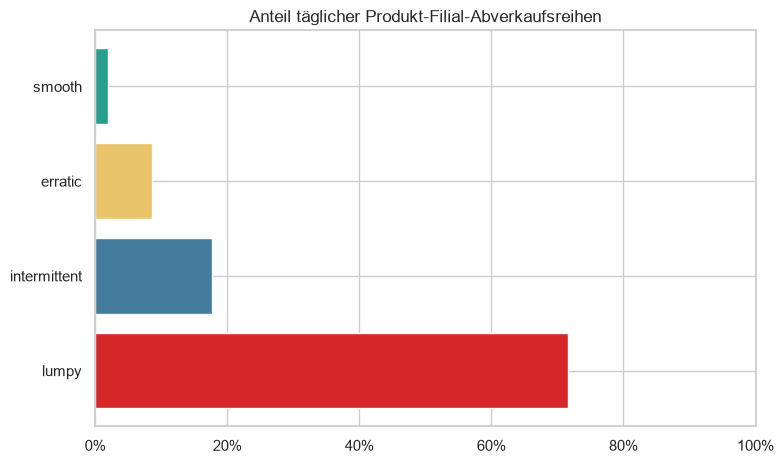

In [6]:
plot_summary = class_summary.set_index("demand_class").reindex(CLASS_ORDER).reset_index()

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.barh(
    plot_summary["demand_class"],
    plot_summary["series_share"],
    color=[CLASS_PALETTE[demand_class] for demand_class in plot_summary["demand_class"]],
)

ax.set_title("Anteil täglicher Produkt-Filial-Abverkaufsreihen")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

plt.tight_layout()


Diese Tabelle gruppiert `smooth` und `erratic` als regelmäßige Abverkaufsreihen sowie `intermittent` und `lumpy` als seltene Abverkaufsreihen.


In [7]:
regular_sparse_share_table = (
    class_summary
    .assign(
        demand_frequency=np.where(
            class_summary["demand_class"].isin(["smooth", "erratic"]),
            "regelmäßige Abverkaufsreihen (%)",
            "seltene Abverkaufsreihen (%)",
        )
    )
    .groupby("demand_frequency", observed=True)["series_share"]
    .sum()
    .mul(100)
    .round(1)
    .reindex(["regelmäßige Abverkaufsreihen (%)", "seltene Abverkaufsreihen (%)"])
    .to_frame()
    .T
)
regular_sparse_share_table.index = ["Anteil"]

regular_sparse_share_table


demand_frequency,regelmäßige Abverkaufsreihen (%),seltene Abverkaufsreihen (%)
Anteil,10.7,89.3


Diese Tabelle zeigt Quartile für ADI, CV2, aktive Tage, Abverkaufstage und Null-Abverkaufsanteil nach Klasse. Sie hilft einzuschätzen, ob Klassen durch typische Verläufe oder durch Grenzfälle geprägt sind.


In [8]:
quantiles = (
    series_classification
    .groupby("demand_class", observed=True)[["ADI", "CV2", "active_days", "demand_days", "zero_day_share"]]
    .quantile([0.25, 0.50, 0.75])
    .round(2)
)
quantiles


ADI   CV2  active_days  demand_days  zero_day_share
demand_class                                                           
smooth       0.25  1.01  0.34        340.0       287.00            0.01
             0.50  1.10  0.40        909.0       721.00            0.09
             0.75  1.19  0.45        909.0       899.00            0.16
erratic      0.25  1.04  0.71        909.0       720.00            0.04
             0.50  1.14  1.09        909.0       786.00            0.12
             0.75  1.24  1.50        909.0       875.75            0.19
intermittent 0.25  3.50  0.32        334.0        62.00            0.71
             0.50  5.16  0.39        791.0       117.00            0.81
             0.75  7.44  0.45        902.0       189.00            0.87
lumpy        0.25  2.10  0.66        868.0       125.00            0.52
             0.50  3.40  0.86        905.0       222.00            0.71
             0.75  5.50  1.15        909.0       388.00            0.82

## Vergleich der Quellgruppen FCM und Pseudo

Dieser Abschnitt untersucht den Zusammenhang zwischen **Quellgruppe** (`is_fcm` bzw. `is_pseudo`) und ADI/CV²-Klasse aus zwei Perspektiven:

1. **Zusammensetzung einer Klasse:** Welcher Anteil der Reihen in `smooth`, `erratic`, `intermittent` und `lumpy` stammt aus FCM bzw. Pseudo?
2. **Klassenprofil einer Quellgruppe:** Wie verteilen sich die FCM-Reihen und die Pseudo-Reihen jeweils auf die vier Klassen?

Beide Nenner sind nötig: Absolute Klassenbestände beantworten die Frage nach der stärksten Repräsentation, werden aber von unterschiedlich großen Produktuniversen beeinflusst. Gruppeninterne Anteile machen FCM und Pseudo trotz ungleicher Gruppengröße vergleichbarer.

**Wichtige Einschränkung:** Der vorgelagerte Minimum-Demand-Filter verwendet quellgruppenspezifische Mindestanforderungen (FCM: mindestens 30 aktive und 10 positive Tage; Pseudo: mindestens 120 aktive und 30 positive Tage). Die Ergebnisse beschreiben deshalb den analysierten, bereits gefilterten Bestand und keine kausale Wirkung der Quellgruppe.

Zuerst werden die FCM-/Pseudo-Flags auf Produkt-Filial-Ebene geprüft. Jede Reihe muss genau einer Quellgruppe angehören, und das Flag darf sich innerhalb einer Reihe nicht ändern.

In [9]:
source_flags = con.execute(
    '''
    SELECT
        ARTIKEL_ID,
        MARKT_ID,
        BOOL_OR(is_fcm) AS is_fcm,
        BOOL_OR(is_pseudo) AS is_pseudo,
        COUNT(DISTINCT is_fcm) AS n_is_fcm_values,
        COUNT(DISTINCT is_pseudo) AS n_is_pseudo_values
    FROM read_parquet(?)
    GROUP BY ARTIKEL_ID, MARKT_ID
    ''',
    [parquet_glob],
).fetchdf()

source_flags["source_group"] = np.select(
    [
        source_flags["is_fcm"] & ~source_flags["is_pseudo"],
        source_flags["is_pseudo"] & ~source_flags["is_fcm"],
    ],
    ["FCM", "Pseudo"],
    default="invalid",
)

flag_audit = pd.DataFrame([
    {
        "series_with_changing_fcm_flag": int((source_flags["n_is_fcm_values"] != 1).sum()),
        "series_with_changing_pseudo_flag": int((source_flags["n_is_pseudo_values"] != 1).sum()),
        "ambiguous_or_missing_source_group": int((source_flags["source_group"] == "invalid").sum()),
    }
])

if flag_audit.to_numpy().sum() != 0:
    raise ValueError(f"Ungültige FCM-/Pseudo-Zuordnung: {flag_audit.iloc[0].to_dict()}")

series_by_source = series_classification.merge(
    source_flags[GROUP_COLS + ["source_group"]],
    on=GROUP_COLS,
    how="left",
    validate="one_to_one",
)
if series_by_source["source_group"].isna().any():
    raise ValueError("Nicht alle klassifizierten Reihen besitzen eine Quellgruppe")

SOURCE_ORDER = ["FCM", "Pseudo"]
SOURCE_PALETTE = {"FCM": "#6a4c93", "Pseudo": "#f28e2b"}
series_by_source["source_group"] = pd.Categorical(
    series_by_source["source_group"], categories=SOURCE_ORDER, ordered=True
)

flag_audit

,series_with_changing_fcm_flag,series_with_changing_pseudo_flag,ambiguous_or_missing_source_group
0,0,0,0


### Größe und Vergleichbarkeit der Gruppen

Die nächste Übersicht trennt die Zahl der Reihen, Produkte und Filialen von den Nachfragekennzahlen. Zusätzlich wird geprüft, ob dieselben Produkte überhaupt in beiden Gruppen vorkommen. Das ist entscheidend für die Interpretation eines FCM-/Pseudo-Unterschieds.

In [10]:
source_summary = (
    series_by_source
    .groupby("source_group", observed=True)
    .agg(
        series=("ARTIKEL_ID", "size"),
        products=("ARTIKEL_ID", "nunique"),
        stores=("MARKT_ID", "nunique"),
        active_days=("active_days", "sum"),
        demand_days=("demand_days", "sum"),
        total_demand_kg=("series_total_demand", "sum"),
        median_ADI=("ADI", "median"),
        median_CV2=("CV2", "median"),
        median_zero_day_share=("zero_day_share", "median"),
        median_series_demand_kg=("series_total_demand", "median"),
    )
    .reindex(SOURCE_ORDER)
)
source_summary["series_share"] = source_summary["series"] / source_summary["series"].sum()
source_summary["demand_share"] = (
    source_summary["total_demand_kg"] / source_summary["total_demand_kg"].sum()
)

source_products = {
    source: set(series_by_source.loc[series_by_source["source_group"] == source, "ARTIKEL_ID"])
    for source in SOURCE_ORDER
}
product_overlap = pd.DataFrame([
    {
        "FCM_products": len(source_products["FCM"]),
        "Pseudo_products": len(source_products["Pseudo"]),
        "products_in_both_groups": len(source_products["FCM"] & source_products["Pseudo"]),
        "products_in_union": len(source_products["FCM"] | source_products["Pseudo"]),
    }
])

source_summary_display = source_summary.reset_index().copy()
source_summary_display["series_share_%"] = (100 * source_summary_display["series_share"]).round(1)
source_summary_display["demand_share_%"] = (100 * source_summary_display["demand_share"]).round(1)
source_summary_display["median_zero_day_share_%"] = (
    100 * source_summary_display["median_zero_day_share"]
).round(1)
source_summary_display[["median_ADI", "median_CV2", "median_series_demand_kg"]] = (
    source_summary_display[["median_ADI", "median_CV2", "median_series_demand_kg"]].round(2)
)

display(source_summary_display[[
    "source_group", "series", "series_share_%", "products", "stores",
    "active_days", "demand_days", "total_demand_kg", "demand_share_%",
    "median_ADI", "median_CV2", "median_zero_day_share_%", "median_series_demand_kg",
]])
display(product_overlap)

,source_group,series,series_share_%,products,stores,active_days,demand_days,total_demand_kg,demand_share_%,median_ADI,median_CV2,median_zero_day_share_%,median_series_demand_kg
0,FCM,3115,14.2,29,192,822781,342254.0,1.713030e+05,0.8,2.77,0.53,63.9,35.50
1,Pseudo,18894,85.8,296,194,16025013,6087482.0,2.122617e+07,99.2,3.44,0.82,71.0,430.94


,FCM_products,Pseudo_products,products_in_both_groups,products_in_union
0,29,296,0,325


### Welche Quellgruppe dominiert in welcher ADI/CV²-Klasse?

Die Tabelle kombiniert drei Sichtweisen:

- `*_n`: absolute Zahl klassifizierter Produkt-Filial-Reihen,
- `*_within_class_%`: Zusammensetzung der jeweiligen ADI/CV²-Klasse,
- `*_within_group_%`: Klassenprofil innerhalb der jeweiligen Quellgruppe.

Das Prävalenzverhältnis vergleicht den gruppeninternen Klassenanteil von FCM mit Pseudo. Ein Wert größer 1 bedeutet, dass die Klasse relativ häufiger unter FCM-Reihen auftritt; ein Wert kleiner 1 spricht für eine relative Überrepräsentation bei Pseudo.

In [11]:
class_source_counts = (
    pd.crosstab(series_by_source["demand_class"], series_by_source["source_group"])
    .reindex(index=CLASS_ORDER, columns=SOURCE_ORDER, fill_value=0)
)
within_class = class_source_counts.div(class_source_counts.sum(axis=1), axis=0)
within_group = class_source_counts.div(class_source_counts.sum(axis=0), axis=1)

class_source_comparison = pd.DataFrame(index=CLASS_ORDER)
for source in SOURCE_ORDER:
    class_source_comparison[f"{source}_n"] = class_source_counts[source]
    class_source_comparison[f"{source}_within_class_%"] = (100 * within_class[source]).round(1)
    class_source_comparison[f"{source}_within_group_%"] = (100 * within_group[source]).round(1)

class_source_comparison["dominant_source"] = within_class.idxmax(axis=1)
class_source_comparison["dominance_margin_pp"] = (
    100 * (within_class.max(axis=1) - within_class.min(axis=1))
).round(1)
class_source_comparison["FCM_to_Pseudo_prevalence_ratio"] = (
    within_group["FCM"] / within_group["Pseudo"].replace(0, np.nan)
).round(2)
class_source_comparison.index.name = "demand_class"

class_source_comparison.reset_index()

,demand_class,FCM_n,FCM_within_class_%,FCM_within_group_%,Pseudo_n,Pseudo_within_class_%,Pseudo_within_group_%,dominant_source,dominance_margin_pp,FCM_to_Pseudo_prevalence_ratio
0,smooth,187,42.2,6.0,256,57.8,1.4,Pseudo,15.6,4.43
1,erratic,121,6.3,3.9,1785,93.7,9.4,Pseudo,87.3,0.41
2,intermittent,1114,28.7,35.8,2773,71.3,14.7,Pseudo,42.7,2.44
3,lumpy,1693,10.7,54.3,14080,89.3,74.5,Pseudo,78.5,0.73


Der linke Plot beantwortet die Frage nach der **Zusammensetzung jeder Klasse**. Der rechte Plot wechselt bewusst den Nenner und zeigt das **Klassenprofil innerhalb von FCM und Pseudo**. Prozentlabels beziehen sich jeweils auf den im Untertitel genannten Nenner.

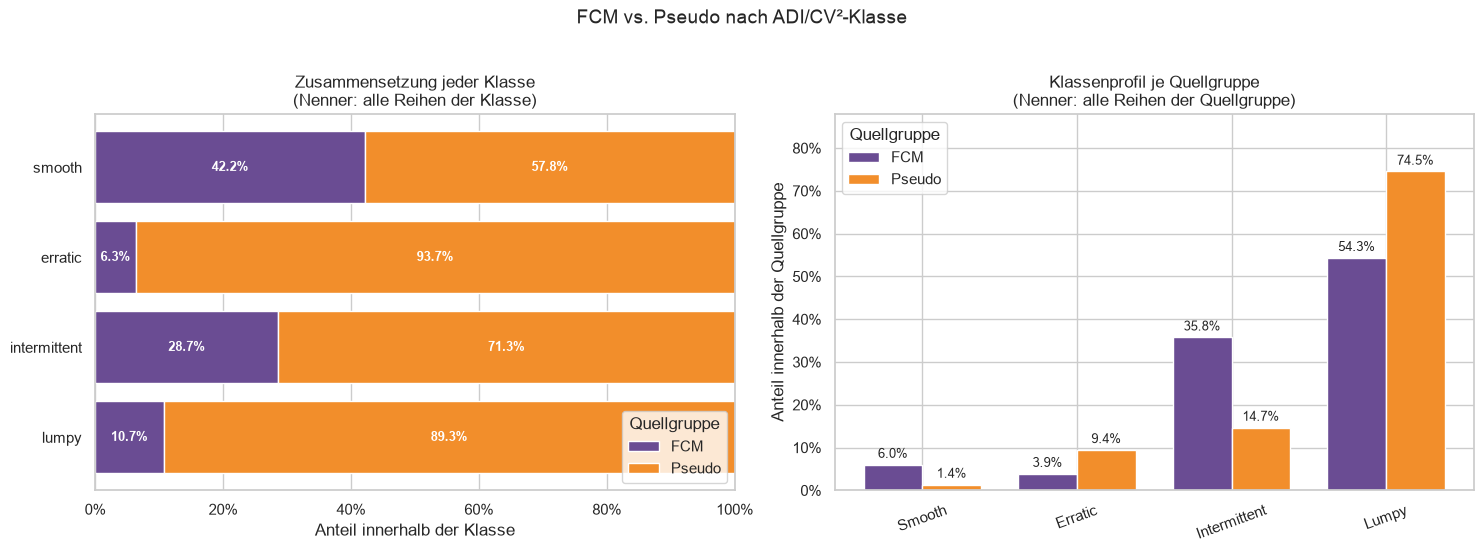

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))

left = axes[0]
left_base = np.zeros(len(CLASS_ORDER))
for source in SOURCE_ORDER:
    values = within_class[source].reindex(CLASS_ORDER).to_numpy()
    bars = left.barh(
        CLASS_ORDER, values, left=left_base,
        color=SOURCE_PALETTE[source], label=source,
    )
    for bar, value in zip(bars, values):
        if value >= 0.045:
            left.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.1%}", ha="center", va="center",
                color="white", fontsize=9, fontweight="bold",
            )
    left_base += values
left.set_title("Zusammensetzung jeder Klasse\n(Nenner: alle Reihen der Klasse)")
left.set_xlabel("Anteil innerhalb der Klasse")
left.set_ylabel("")
left.set_xlim(0, 1)
left.invert_yaxis()
left.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
left.legend(title="Quellgruppe", loc="lower right")

right = axes[1]
x = np.arange(len(CLASS_ORDER))
width = 0.38
for i, source in enumerate(SOURCE_ORDER):
    values = within_group[source].reindex(CLASS_ORDER).to_numpy()
    bars = right.bar(
        x + (i - 0.5) * width, values, width,
        color=SOURCE_PALETTE[source], label=source,
    )
    right.bar_label(bars, labels=[f"{value:.1%}" for value in values], padding=3, fontsize=9)
right.set_title("Klassenprofil je Quellgruppe\n(Nenner: alle Reihen der Quellgruppe)")
right.set_xlabel("")
right.set_ylabel("Anteil innerhalb der Quellgruppe")
right.set_xticks(x, [label.capitalize() for label in CLASS_ORDER], rotation=20)
right.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
right.set_ylim(0, max(within_group.max()) * 1.18)
right.legend(title="Quellgruppe")

fig.suptitle("FCM vs. Pseudo nach ADI/CV²-Klasse", fontsize=14, y=1.02)
plt.tight_layout()

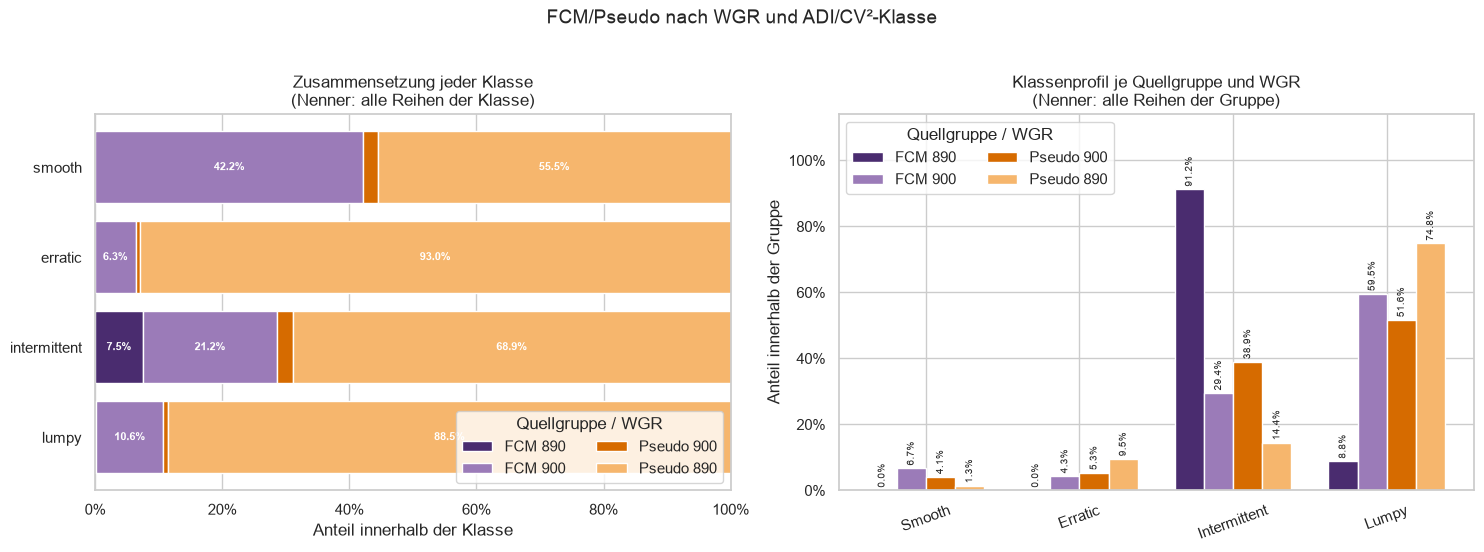

In [13]:
SOURCE_WGR_ORDER = ["FCM 890", "FCM 900", "Pseudo 900", "Pseudo 890"]
SOURCE_WGR_PALETTE = {
    "FCM 890": "#4a2c6f",
    "FCM 900": "#9b7bb8",
    "Pseudo 900": "#d66b00",
    "Pseudo 890": "#f6b66d",
}

series_wgr = con.execute(
    '''
    SELECT
        ARTIKEL_ID,
        MARKT_ID,
        MIN(WGR_ID) AS WGR_ID,
        COUNT(DISTINCT WGR_ID) AS n_wgr_values
    FROM read_parquet(?)
    GROUP BY ARTIKEL_ID, MARKT_ID
    ''',
    [parquet_glob],
).fetchdf()
if (series_wgr["n_wgr_values"] != 1).any():
    raise ValueError("WGR_ID ist innerhalb mindestens einer Produkt-Filial-Reihe nicht konstant")

series_by_source_wgr = series_by_source.merge(
    series_wgr[GROUP_COLS + ["WGR_ID"]],
    on=GROUP_COLS,
    how="left",
    validate="one_to_one",
)
series_by_source_wgr = series_by_source_wgr.loc[
    series_by_source_wgr["WGR_ID"].isin([890, 900])
].copy()
series_by_source_wgr["source_wgr_group"] = (
    series_by_source_wgr["source_group"].astype("string")
    + " "
    + series_by_source_wgr["WGR_ID"].astype("Int64").astype("string")
)

class_source_wgr_counts = (
    pd.crosstab(
        series_by_source_wgr["demand_class"],
        series_by_source_wgr["source_wgr_group"],
    )
    .reindex(index=CLASS_ORDER, columns=SOURCE_WGR_ORDER, fill_value=0)
)
within_class_wgr = class_source_wgr_counts.div(
    class_source_wgr_counts.sum(axis=1).replace(0, np.nan), axis=0
)
within_source_wgr = class_source_wgr_counts.div(
    class_source_wgr_counts.sum(axis=0).replace(0, np.nan), axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))

left = axes[0]
left_base = np.zeros(len(CLASS_ORDER))
for group in SOURCE_WGR_ORDER:
    values = within_class_wgr[group].reindex(CLASS_ORDER).fillna(0).to_numpy()
    bars = left.barh(
        CLASS_ORDER, values, left=left_base,
        color=SOURCE_WGR_PALETTE[group], label=group,
    )
    for bar, value in zip(bars, values):
        if value >= 0.045:
            left.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.1%}", ha="center", va="center",
                color="white", fontsize=8, fontweight="bold",
            )
    left_base += values
left.set_title("Zusammensetzung jeder Klasse\n(Nenner: alle Reihen der Klasse)")
left.set_xlabel("Anteil innerhalb der Klasse")
left.set_ylabel("")
left.set_xlim(0, 1)
left.invert_yaxis()
left.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
left.legend(title="Quellgruppe / WGR", loc="lower right", ncols=2)

right = axes[1]
x = np.arange(len(CLASS_ORDER))
width = 0.19
for i, group in enumerate(SOURCE_WGR_ORDER):
    values = within_source_wgr[group].reindex(CLASS_ORDER).fillna(0).to_numpy()
    bars = right.bar(
        x + (i - (len(SOURCE_WGR_ORDER) - 1) / 2) * width, values, width,
        color=SOURCE_WGR_PALETTE[group], label=group,
    )
    right.bar_label(
        bars, labels=[f"{value:.1%}" for value in values],
        padding=2, fontsize=7, rotation=90,
    )
right.set_title("Klassenprofil je Quellgruppe und WGR\n(Nenner: alle Reihen der Gruppe)")
right.set_xlabel("")
right.set_ylabel("Anteil innerhalb der Gruppe")
right.set_xticks(x, [label.capitalize() for label in CLASS_ORDER], rotation=20)
right.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
right.set_ylim(0, max(within_source_wgr.max()) * 1.25)
right.legend(title="Quellgruppe / WGR", ncols=2)

fig.suptitle("FCM/Pseudo nach WGR und ADI/CV²-Klasse", fontsize=14, y=1.02)
plt.tight_layout()

### Beispielprodukte aus FCM 890 und Pseudo 900

Je Gruppe werden zwei unterschiedliche Produkte ausgewählt, deren Produkt-Filial-Reihen möglichst nahe am gruppentypischen medianen ADI- und CV²-Wert liegen.

,source_wgr_group,example_number,demand_class,ARTIKEL_ID,ARTIKEL_BEZ,ARTIKEL_INHALT,active_days,demand_days,ADI,CV2
0,FCM 890,1,intermittent,1406590,SB Puszta Gulasch vom Schwein,1 Kilogramm,244,39.0,6.26,0.21
1,FCM 890,2,intermittent,1406587,SB Snirtje Braten vom Schwein,1 Kilogramm,245,37.0,6.62,0.21
2,Pseudo 900,1,lumpy,1227594,Mettenden Tüte (5x75g),5 x 75 Gramm,126,38.0,3.32,0.53
3,Pseudo 900,2,lumpy,594066,Pfefferbeisser Stück,60 Gramm,104,34.0,3.06,0.54


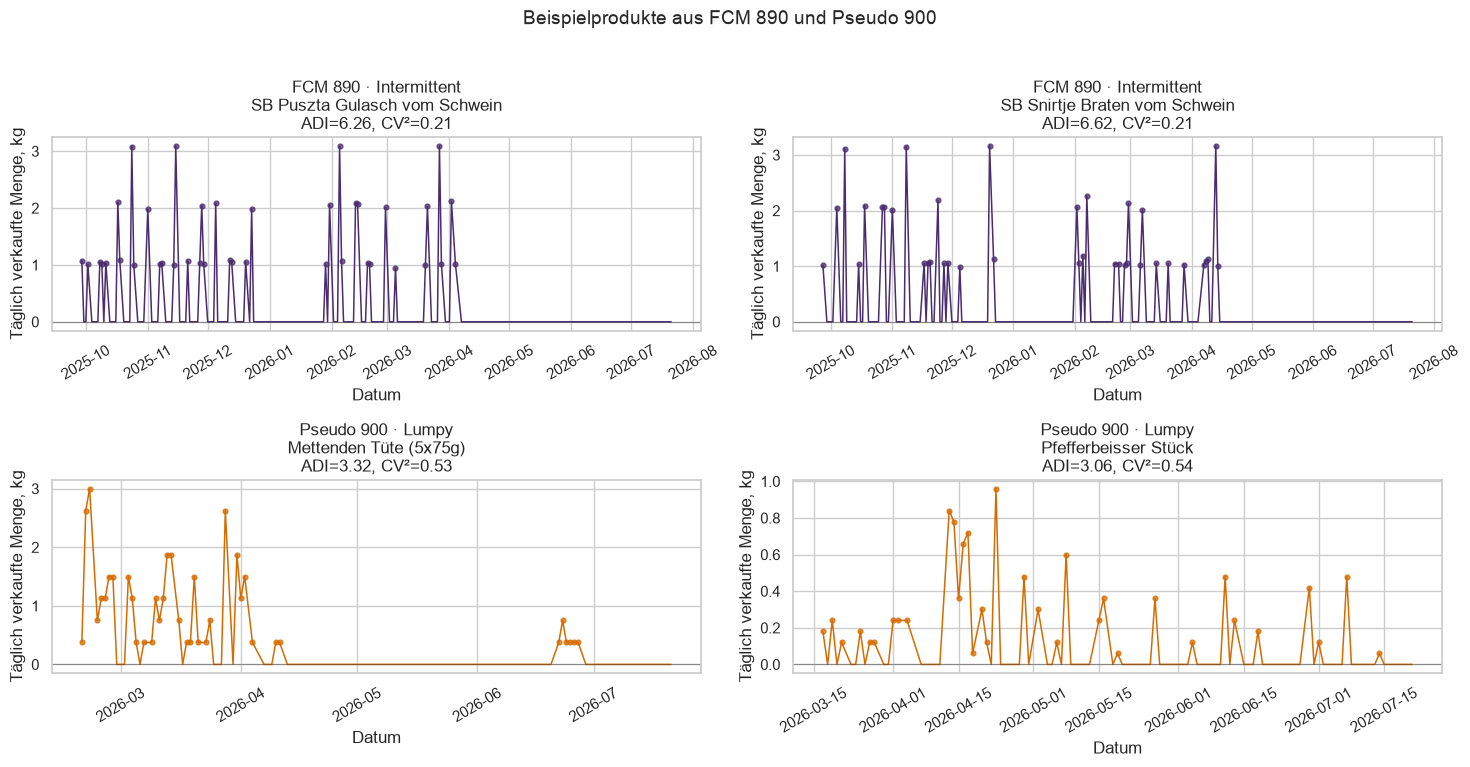

In [14]:
EXAMPLE_GROUP_ORDER = ["FCM 890", "Pseudo 900"]
EXAMPLES_PER_GROUP = 2

example_metadata = con.execute(
    '''
    SELECT
        ARTIKEL_ID,
        MARKT_ID,
        MIN(ARTIKEL_BEZ) AS ARTIKEL_BEZ,
        MIN(ARTIKEL_INHALT) AS ARTIKEL_INHALT,
        MIN(VERKAUFSEINHEIT) AS VERKAUFSEINHEIT
    FROM read_parquet(?)
    WHERE WGR_ID IN (890, 900)
    GROUP BY ARTIKEL_ID, MARKT_ID
    ''',
    [parquet_glob],
).fetchdf()

example_candidates = series_by_source_wgr[
    series_by_source_wgr["source_wgr_group"].isin(EXAMPLE_GROUP_ORDER)
].merge(example_metadata, on=GROUP_COLS, how="left", validate="one_to_one")
group_medians = (
    example_candidates
    .groupby("source_wgr_group", observed=True)[["ADI", "CV2"]]
    .median()
    .rename(columns={"ADI": "group_median_ADI", "CV2": "group_median_CV2"})
)
example_candidates = example_candidates.join(group_medians, on="source_wgr_group")
example_candidates["median_distance"] = (
    (example_candidates["ADI"] - example_candidates["group_median_ADI"]).abs()
    / example_candidates["group_median_ADI"].abs().clip(lower=1e-12)
    + (example_candidates["CV2"] - example_candidates["group_median_CV2"]).abs()
    / example_candidates["group_median_CV2"].abs().clip(lower=1e-12)
)

selected_wgr_examples = (
    example_candidates
    .sort_values(
        ["source_wgr_group", "median_distance", "active_days"],
        ascending=[True, True, False],
    )
    .drop_duplicates(["source_wgr_group", "ARTIKEL_ID"])
    .groupby("source_wgr_group", observed=True, group_keys=False)
    .head(EXAMPLES_PER_GROUP)
    .copy()
)
example_counts = selected_wgr_examples["source_wgr_group"].value_counts()
if any(example_counts.get(group, 0) < EXAMPLES_PER_GROUP for group in EXAMPLE_GROUP_ORDER):
    raise ValueError(f"Zu wenige unterschiedliche Beispielprodukte: {example_counts.to_dict()}")

selected_wgr_examples["group_order"] = selected_wgr_examples["source_wgr_group"].map(
    {group: i for i, group in enumerate(EXAMPLE_GROUP_ORDER)}
)
selected_wgr_examples = selected_wgr_examples.sort_values(
    ["group_order", "median_distance"]
).reset_index(drop=True)
selected_wgr_examples["example_number"] = (
    selected_wgr_examples.groupby("source_wgr_group", sort=False).cumcount() + 1
)

display(selected_wgr_examples[[
    "source_wgr_group", "example_number", "demand_class",
    "ARTIKEL_ID", "ARTIKEL_BEZ", "ARTIKEL_INHALT",
    "active_days", "demand_days", "ADI", "CV2",
]].round({"ADI": 2, "CV2": 2}))

example_keys = selected_wgr_examples[[
    "source_wgr_group", "example_number", "ARTIKEL_ID", "MARKT_ID"
]].copy()
con.register("wgr_example_keys", example_keys)
example_ts = con.execute(
    f'''
    SELECT
        k.source_wgr_group,
        k.example_number,
        d.ARTIKEL_ID,
        d.MARKT_ID,
        CAST(d.DATE AS DATE) AS sale_date,
        SUM(CAST(COALESCE(d.{DEMAND_COL}, 0) AS DOUBLE)) AS demand
    FROM read_parquet(?) AS d
    JOIN wgr_example_keys AS k
        ON d.ARTIKEL_ID = k.ARTIKEL_ID
        AND d.MARKT_ID = k.MARKT_ID
    WHERE d.is_active
    GROUP BY
        k.source_wgr_group, k.example_number,
        d.ARTIKEL_ID, d.MARKT_ID, sale_date
    ORDER BY k.source_wgr_group, k.example_number, sale_date
    ''',
    [parquet_glob],
).fetchdf()
example_plot_data = example_ts.merge(
    selected_wgr_examples[[
        "source_wgr_group", "example_number", "ARTIKEL_ID", "MARKT_ID",
        "demand_class", "ARTIKEL_BEZ", "ADI", "CV2",
    ]],
    on=["source_wgr_group", "example_number", "ARTIKEL_ID", "MARKT_ID"],
    how="left",
)

fig, axes = plt.subplots(2, 2, figsize=(15, 7.5), sharex=False)
for row_index, group in enumerate(EXAMPLE_GROUP_ORDER):
    for column_index in range(EXAMPLES_PER_GROUP):
        example_number = column_index + 1
        ax = axes[row_index, column_index]
        subset = example_plot_data[
            example_plot_data["source_wgr_group"].eq(group)
            & example_plot_data["example_number"].eq(example_number)
        ].sort_values("sale_date")
        meta = subset.iloc[0]
        color = SOURCE_WGR_PALETTE[group]
        positive = subset[subset["demand"] > 0]
        article_name = str(meta["ARTIKEL_BEZ"])
        if len(article_name) > 48:
            article_name = article_name[:45] + "..."

        ax.plot(subset["sale_date"], subset["demand"], color=color, linewidth=1.1)
        ax.scatter(
            positive["sale_date"], positive["demand"],
            color=color, s=12, alpha=0.75,
        )
        ax.axhline(0, color="#444444", linewidth=0.8, alpha=0.5)
        ax.set_title(
            f"{group} · {meta['demand_class'].capitalize()}\n"
            f"{article_name}\n"
            f"ADI={meta['ADI']:.2f}, CV²={meta['CV2']:.2f}"
        )
        ax.set_xlabel("Datum")
        ax.set_ylabel("Täglich verkaufte Menge, kg")
        ax.tick_params(axis="x", rotation=30)

fig.suptitle("Beispielprodukte aus FCM 890 und Pseudo 900", fontsize=14, y=1.02)
plt.tight_layout()

### Stärke des Zusammenhangs

Ein Chi-Quadrat-Test prüft, ob Quellgruppe und ADI/CV²-Klasse unabhängig sind. Wegen der großen Stichprobe ist der p-Wert allein wenig aussagekräftig; deshalb wird zusätzlich **Cramérs V** als Effektstärke berichtet. Die standardisierten Residuen zeigen, welche Kombinationen stärker (`> 0`) oder schwächer (`< 0`) besetzt sind als unter Unabhängigkeit erwartet.

Die Produkt-Filial-Reihen sind nicht vollständig unabhängig, weil Produkte und Filialen mehrfach vorkommen. Der Test ist deshalb deskriptiv zu interpretieren und nicht als kausaler Nachweis.

,chi2,degrees_of_freedom,p_value,cramers_V,n_series
0,1207.64,3,1.61e-261,0.234,22009


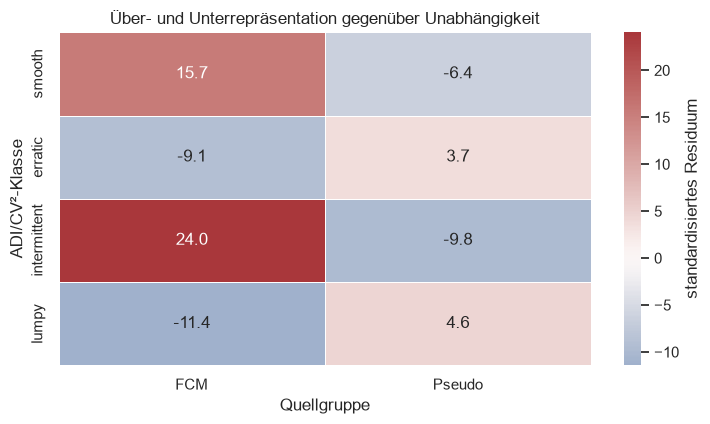

In [15]:
from scipy.stats import chi2_contingency

chi2_stat, chi2_p, chi2_dof, expected = chi2_contingency(class_source_counts)
n_observations = class_source_counts.to_numpy().sum()
cramers_v = np.sqrt(
    chi2_stat
    / (n_observations * min(class_source_counts.shape[0] - 1, class_source_counts.shape[1] - 1))
)
standardized_residuals = pd.DataFrame(
    (class_source_counts.to_numpy() - expected) / np.sqrt(expected),
    index=CLASS_ORDER,
    columns=SOURCE_ORDER,
)

association_summary = pd.DataFrame([
    {
        "chi2": chi2_stat,
        "degrees_of_freedom": chi2_dof,
        "p_value": f"{chi2_p:.2e}",
        "cramers_V": cramers_v,
        "n_series": n_observations,
    }
]).round({"chi2": 2, "cramers_V": 3})
display(association_summary)

fig, ax = plt.subplots(figsize=(7.5, 4.4))
sns.heatmap(
    standardized_residuals,
    annot=True,
    fmt=".1f",
    cmap="vlag",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "standardisiertes Residuum"},
    ax=ax,
)
ax.set_title("Über- und Unterrepräsentation gegenüber Unabhängigkeit")
ax.set_xlabel("Quellgruppe")
ax.set_ylabel("ADI/CV²-Klasse")
plt.tight_layout()

### Kennzahlen innerhalb derselben ADI/CV²-Klasse

Diese Tabelle vergleicht FCM und Pseudo **innerhalb** jeder Klasse. So wird sichtbar, ob sich Reihen trotz gleicher grober Klassenzuordnung noch in der Lage ihrer ADI-/CV²-Werte, im Nulltageanteil, in der Historienlänge und im Nachfragevolumen unterscheiden.

In [16]:
source_class_metrics = (
    series_by_source
    .groupby(["demand_class", "source_group"], observed=True)
    .agg(
        series=("ARTIKEL_ID", "size"),
        products=("ARTIKEL_ID", "nunique"),
        stores=("MARKT_ID", "nunique"),
        median_active_days=("active_days", "median"),
        median_demand_days=("demand_days", "median"),
        median_ADI=("ADI", "median"),
        median_CV2=("CV2", "median"),
        median_zero_day_share=("zero_day_share", "median"),
        median_series_demand_kg=("series_total_demand", "median"),
    )
    .reindex(pd.MultiIndex.from_product(
        [CLASS_ORDER, SOURCE_ORDER], names=["demand_class", "source_group"]
    ))
    .reset_index()
)
source_class_metrics["median_zero_day_share_%"] = (
    100 * source_class_metrics["median_zero_day_share"]
).round(1)
source_class_metrics[[
    "median_active_days", "median_demand_days", "median_ADI",
    "median_CV2", "median_series_demand_kg",
]] = source_class_metrics[[
    "median_active_days", "median_demand_days", "median_ADI",
    "median_CV2", "median_series_demand_kg",
]].round(2)

source_class_metrics[[
    "demand_class", "source_group", "series", "products", "stores",
    "median_active_days", "median_demand_days", "median_ADI", "median_CV2",
    "median_zero_day_share_%", "median_series_demand_kg",
]]

,demand_class,source_group,series,products,stores,median_active_days,median_demand_days,median_ADI,median_CV2,median_zero_day_share_%,median_series_demand_kg
0,smooth,FCM,187,12,87,340.0,287.0,1.18,0.41,15.1,142.72
1,smooth,Pseudo,256,26,116,909.0,893.0,1.02,0.39,1.5,3876.60
2,erratic,FCM,121,15,70,338.0,274.0,1.19,0.57,15.8,125.72
3,erratic,Pseudo,1785,66,189,909.0,797.0,1.13,1.11,11.9,3354.95
4,intermittent,FCM,1114,27,190,246.0,56.0,3.70,0.38,73.0,33.40
5,intermittent,Pseudo,2773,217,194,895.0,135.0,5.51,0.40,81.8,143.07
6,lumpy,FCM,1693,24,190,280.0,80.0,2.87,0.69,65.2,28.87
7,lumpy,Pseudo,14080,267,193,908.0,247.0,3.47,0.88,71.1,430.06


Die empirischen Verteilungsfunktionen zeigen die vollständigen Verteilungen statt nur eines Medians. ADI und Gesamtnachfrage werden wegen ihrer langen rechten Verteilung logarithmisch dargestellt. Gestrichelte Linien markieren die ADI-/CV²-Klassifikationsgrenzen.

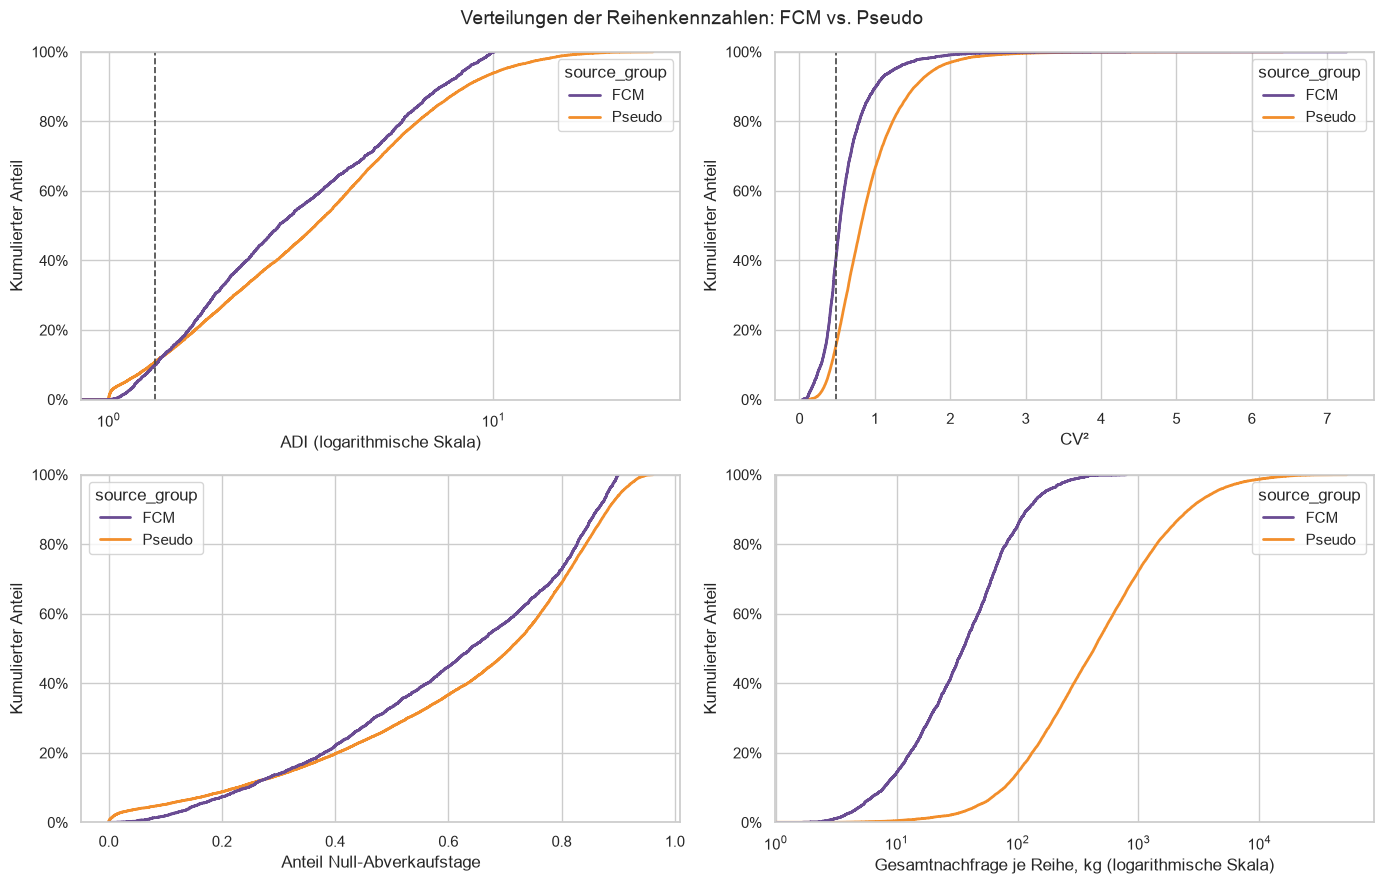

In [17]:
distribution_specs = [
    ("ADI", "ADI (logarithmische Skala)", "log", ADI_CUTOFF),
    ("CV2", "CV²", "linear", CV2_CUTOFF),
    ("zero_day_share", "Anteil Null-Abverkaufstage", "linear", None),
    ("series_total_demand", "Gesamtnachfrage je Reihe, kg (logarithmische Skala)", "log", None),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, (column, xlabel, scale, cutoff) in zip(axes.ravel(), distribution_specs):
    sns.ecdfplot(
        data=series_by_source,
        x=column,
        hue="source_group",
        hue_order=SOURCE_ORDER,
        palette=SOURCE_PALETTE,
        linewidth=2,
        ax=ax,
    )
    if scale == "log":
        ax.set_xscale("log")
    if cutoff is not None:
        ax.axvline(cutoff, color="#444444", linestyle="--", linewidth=1.2, label="Klassengrenze")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Kumulierter Anteil")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")

fig.suptitle("Verteilungen der Reihenkennzahlen: FCM vs. Pseudo", fontsize=14)
plt.tight_layout()

### Robustheitsblick auf Filialebene

Da fast dieselben Filialen beide Quellgruppen führen, werden die Klassenanteile zusätzlich innerhalb jeder Kombination aus Filiale und Quellgruppe berechnet. Der Median und der Interquartilsabstand über Filialen verhindern, dass Filialen mit besonders vielen Produkten die Gesamtsicht allein dominieren. Dieser Schritt gleicht jedoch nicht die unterschiedlichen Produktlisten aus.

,demand_class,source_group,stores,p25_%,median_%,p75_%
0,smooth,FCM,192,0.0,0.0,10.7
1,smooth,Pseudo,194,0.0,0.9,2.4
2,erratic,FCM,192,0.0,0.0,5.6
3,erratic,Pseudo,194,5.3,8.8,11.8
4,intermittent,FCM,192,25.0,35.3,50.0
5,intermittent,Pseudo,194,10.8,14.1,18.4
6,lumpy,FCM,192,45.0,53.3,62.5
7,lumpy,Pseudo,194,71.1,74.7,78.2


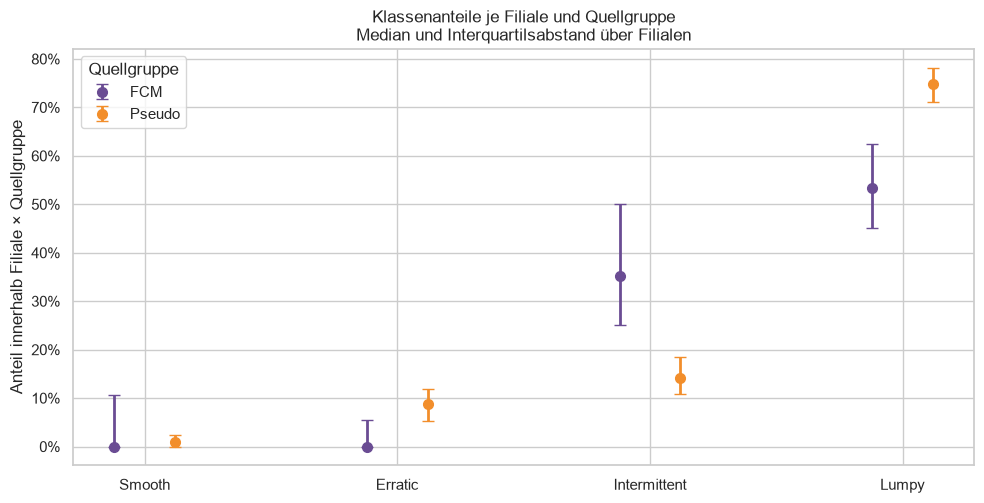

In [18]:
store_class_shares = (
    series_by_source
    .groupby(["MARKT_ID", "source_group", "demand_class"], observed=True)
    .size()
    .rename("series")
    .reset_index()
)
store_group_totals = (
    series_by_source
    .groupby(["MARKT_ID", "source_group"], observed=True)
    .size()
    .rename("group_series")
    .reset_index()
)
store_class_grid = pd.MultiIndex.from_product(
    [
        series_by_source["MARKT_ID"].unique(),
        SOURCE_ORDER,
        CLASS_ORDER,
    ],
    names=["MARKT_ID", "source_group", "demand_class"],
).to_frame(index=False)
store_class_shares = (
    store_class_grid
    .merge(store_group_totals, on=["MARKT_ID", "source_group"], how="left")
    .dropna(subset=["group_series"])
    .merge(
        store_class_shares,
        on=["MARKT_ID", "source_group", "demand_class"],
        how="left",
    )
)
store_class_shares["series"] = store_class_shares["series"].fillna(0)
store_class_shares["class_share"] = (
    store_class_shares["series"] / store_class_shares["group_series"]
)

store_level_summary = (
    store_class_shares
    .groupby(["demand_class", "source_group"], observed=True)["class_share"]
    .agg(
        stores="size",
        p25=lambda values: values.quantile(0.25),
        median="median",
        p75=lambda values: values.quantile(0.75),
    )
    .reindex(pd.MultiIndex.from_product(
        [CLASS_ORDER, SOURCE_ORDER], names=["demand_class", "source_group"]
    ))
    .reset_index()
)

store_level_display = store_level_summary.copy()
for column in ["p25", "median", "p75"]:
    store_level_display[f"{column}_%"] = (100 * store_level_display[column]).round(1)
display(store_level_display[[
    "demand_class", "source_group", "stores", "p25_%", "median_%", "p75_%"
]])

fig, ax = plt.subplots(figsize=(10, 5.2))
x = np.arange(len(CLASS_ORDER))
offsets = {"FCM": -0.12, "Pseudo": 0.12}
for source in SOURCE_ORDER:
    subset = store_level_summary[store_level_summary["source_group"] == source].set_index("demand_class").loc[CLASS_ORDER]
    positions = x + offsets[source]
    lower = subset["median"] - subset["p25"]
    upper = subset["p75"] - subset["median"]
    ax.errorbar(
        positions,
        subset["median"],
        yerr=np.vstack([lower, upper]),
        fmt="o",
        capsize=4,
        linewidth=2,
        markersize=7,
        color=SOURCE_PALETTE[source],
        label=source,
    )
ax.set_title("Klassenanteile je Filiale und Quellgruppe\nMedian und Interquartilsabstand über Filialen")
ax.set_xticks(x, [label.capitalize() for label in CLASS_ORDER])
ax.set_ylabel("Anteil innerhalb Filiale × Quellgruppe")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.0%}")
ax.legend(title="Quellgruppe")
plt.tight_layout()

### Automatisch berechnete Kernaussagen

Die folgende Zelle formuliert die wichtigsten Resultate direkt aus den Tabellen, damit Text und neu ausgeführte Datenstände konsistent bleiben.

In [19]:
from IPython.display import Markdown, display

dominant_lines = []
for demand_class in CLASS_ORDER:
    row = class_source_comparison.loc[demand_class]
    dominant = row["dominant_source"]
    dominant_share = row[f"{dominant}_within_class_%"]
    dominant_lines.append(
        f"- **{demand_class.capitalize()}:** {dominant} stellt {dominant_share:.1f}% "
        f"der Reihen (Vorsprung {row['dominance_margin_pp']:.1f} Prozentpunkte)."
    )

fcm_top_class = within_group["FCM"].idxmax()
pseudo_top_class = within_group["Pseudo"].idxmax()
fcm_top_share = 100 * within_group.loc[fcm_top_class, "FCM"]
pseudo_top_share = 100 * within_group.loc[pseudo_top_class, "Pseudo"]
common_products = product_overlap.loc[0, "products_in_both_groups"]

display(Markdown(
    "**Dominante Quellgruppe innerhalb jeder Klasse**\n\n"
    + "\n".join(dominant_lines)
    + "\n\n**Gruppeninterne Profile**\n\n"
    + f"- Unter FCM ist **{fcm_top_class}** mit {fcm_top_share:.1f}% die häufigste Klasse.\n"
    + f"- Unter Pseudo ist **{pseudo_top_class}** mit {pseudo_top_share:.1f}% die häufigste Klasse.\n"
    + f"- Der Zusammenhang hat Cramérs V = **{cramers_v:.3f}**; der Chi-Quadrat-p-Wert beträgt {chi2_p:.2e}.\n\n"
    + "**Interpretationsgrenze**\n\n"
    + f"- Die Gruppen teilen **{common_products} Produkte**. Damit sind Quellgruppe und Produktsortiment vollständig "
      "konfundiert; Unterschiede dürfen nicht als isolierter FCM-/Pseudo-Effekt interpretiert werden.\n"
    + "- Absolute Dominanz beantwortet, wer in einer Klasse mengenmäßig stärker vertreten ist. "
      "Gruppeninterne und filialweise Anteile sind für den strukturellen Vergleich aussagekräftiger."
))

**Dominante Quellgruppe innerhalb jeder Klasse**

- **Smooth:** Pseudo stellt 57.8% der Reihen (Vorsprung 15.6 Prozentpunkte).
- **Erratic:** Pseudo stellt 93.7% der Reihen (Vorsprung 87.3 Prozentpunkte).
- **Intermittent:** Pseudo stellt 71.3% der Reihen (Vorsprung 42.7 Prozentpunkte).
- **Lumpy:** Pseudo stellt 89.3% der Reihen (Vorsprung 78.5 Prozentpunkte).

**Gruppeninterne Profile**

- Unter FCM ist **lumpy** mit 54.3% die häufigste Klasse.
- Unter Pseudo ist **lumpy** mit 74.5% die häufigste Klasse.
- Der Zusammenhang hat Cramérs V = **0.234**; der Chi-Quadrat-p-Wert beträgt 1.61e-261.

**Interpretationsgrenze**

- Die Gruppen teilen **0 Produkte**. Damit sind Quellgruppe und Produktsortiment vollständig konfundiert; Unterschiede dürfen nicht als isolierter FCM-/Pseudo-Effekt interpretiert werden.
- Absolute Dominanz beantwortet, wer in einer Klasse mengenmäßig stärker vertreten ist. Gruppeninterne und filialweise Anteile sind für den strukturellen Vergleich aussagekräftiger.

## Vier repräsentative tägliche Abverkaufsreihen

Die vier Beispiele wählen je eine Produkt-Filial-Reihe pro ADI/CV2-Klasse aus. Die Auswahl folgt der gleichen Idee wie im Notebook zur wöchentlichen Heterogenität: stabile Artikelmetadaten werden bevorzugt, und zuerst wird versucht, dasselbe Produkt über verschiedene Filialen hinweg zu zeigen.


Diese Zelle wählt vier repräsentative Produkt-Filial-Reihen aus den Tagesdaten aus, jeweils eine pro ADI/CV2-Klasse. Nach Möglichkeit wird dasselbe Produkt über verschiedene Filialen verwendet, damit die Panels Filialunterschiede für ein vergleichbares Produkt zeigen.


In [20]:
PREFERRED_MIN_ACTIVE_DAYS = 120
daily_glob = parquet_glob

daily_classification = series_classification.copy()
daily_classification["demand_class"] = daily_classification["demand_class"].astype(str)

daily_class_medians = (
    daily_classification
    .groupby("demand_class", observed=True)[["ADI", "CV2"]]
    .median()
    .rename(columns={"ADI": "class_median_ADI", "CV2": "class_median_CV2"})
)

daily_metadata = con.execute(
    """
    SELECT
        ARTIKEL_ID,
        MARKT_ID,
        MIN(ARTIKEL_BEZ) AS ARTIKEL_BEZ,
        MIN(ARTIKEL_INHALT) AS ARTIKEL_INHALT,
        MIN(VERKAUFSEINHEIT) AS VERKAUFSEINHEIT,
        MIN(GEWICHTSARTIKEL) AS GEWICHTSARTIKEL,
        COUNT(DISTINCT ARTIKEL_INHALT) AS n_artikel_inhalt,
        COUNT(DISTINCT VERKAUFSEINHEIT) AS n_verkaufseinheit,
        COUNT(DISTINCT GEWICHTSARTIKEL) AS n_gewichtsartikel
    FROM read_parquet(?)
    GROUP BY ARTIKEL_ID, MARKT_ID
    """,
    [daily_glob],
).fetchdf()

daily_examples_base = daily_classification.merge(
    daily_metadata, on=GROUP_COLS, how="left"
)

stable_metadata = (
    (daily_examples_base["n_artikel_inhalt"] == 1)
    & (daily_examples_base["n_verkaufseinheit"] == 1)
    & (daily_examples_base["n_gewichtsartikel"] == 1)
)
daily_metadata_candidates = daily_examples_base[stable_metadata].copy()


def score_daily_example_candidates(candidates):
    scored = candidates.merge(daily_class_medians, on="demand_class", how="left").copy()
    scored["median_distance"] = (
        (scored["ADI"] - scored["class_median_ADI"]).abs()
        / scored["class_median_ADI"].replace(0, np.nan)
        + (scored["CV2"] - scored["class_median_CV2"]).abs()
        / scored["class_median_CV2"].replace(0, np.nan)
    )
    return scored


def has_all_daily_classes(candidates):
    return set(candidates["demand_class"].dropna()).issuperset(CLASS_ORDER)


def select_same_daily_article(candidates):
    if candidates.empty or not has_all_daily_classes(candidates):
        return pd.DataFrame()

    scored = score_daily_example_candidates(candidates)
    best_per_article_class = (
        scored
        .sort_values(
            ["ARTIKEL_ID", "demand_class", "median_distance", "active_days"],
            ascending=[True, True, True, False],
        )
        .groupby(["ARTIKEL_ID", "demand_class"], observed=True)
        .head(1)
    )

    article_scores = (
        best_per_article_class
        .groupby("ARTIKEL_ID", observed=True)
        .agg(
            n_classes=("demand_class", "nunique"),
            total_distance=("median_distance", "sum"),
            median_active_days=("active_days", "median"),
            ARTIKEL_BEZ=("ARTIKEL_BEZ", "first"),
            ARTIKEL_INHALT=("ARTIKEL_INHALT", "first"),
        )
        .loc[lambda df: df["n_classes"].eq(len(CLASS_ORDER))]
        .sort_values(["total_distance", "median_active_days"], ascending=[True, False])
    )

    if article_scores.empty:
        return pd.DataFrame()

    selected_article_id = article_scores.index[0]
    return (
        best_per_article_class[best_per_article_class["ARTIKEL_ID"].eq(selected_article_id)]
        .set_index("demand_class")
        .loc[CLASS_ORDER]
        .reset_index()
    )


def select_daily_per_class(candidates):
    if candidates.empty or not has_all_daily_classes(candidates):
        return pd.DataFrame()

    return (
        score_daily_example_candidates(candidates)
        .sort_values(
            ["demand_class", "median_distance", "active_days"],
            ascending=[True, True, False],
        )
        .groupby("demand_class", observed=True)
        .head(1)
        .set_index("demand_class")
        .loc[CLASS_ORDER]
        .reset_index()
    )


daily_candidate_pools = [
    (
        "gleiches Produkt in vier Filialen/Klassen, stabile Metadaten, active_days >= "
        f"{PREFERRED_MIN_ACTIVE_DAYS}",
        daily_metadata_candidates[
            daily_metadata_candidates["active_days"] >= PREFERRED_MIN_ACTIVE_DAYS
        ],
        select_same_daily_article,
    ),
    (
        "gleiches Produkt in vier Filialen/Klassen, stabile Metadaten",
        daily_metadata_candidates,
        select_same_daily_article,
    ),
    (
        "eine stabile Reihe pro Klasse, active_days >= "
        f"{PREFERRED_MIN_ACTIVE_DAYS}",
        daily_metadata_candidates[
            daily_metadata_candidates["active_days"] >= PREFERRED_MIN_ACTIVE_DAYS
        ],
        select_daily_per_class,
    ),
    ("eine stabile Reihe pro Klasse", daily_metadata_candidates, select_daily_per_class),
    ("eine Reihe pro Klasse", daily_examples_base, select_daily_per_class),
]

for daily_selection_note, candidates, selector in daily_candidate_pools:
    daily_example_series = selector(candidates)
    if not daily_example_series.empty:
        break
else:
    available = (
        daily_classification.groupby("demand_class", observed=True)
        .size()
        .reindex(CLASS_ORDER)
        .fillna(0)
        .astype(int)
    )
    raise ValueError(
        "Es konnte nicht je ein tägliches Beispiel pro Klasse ausgewählt werden. "
        f"Verfügbare Reihen je Klasse: {available.to_dict()}"
    )

daily_example_series = daily_example_series.copy()
daily_example_series["store_label"] = [
    f"Filiale {chr(65 + i)}" for i in range(len(daily_example_series))
]

daily_example_display_cols = [
    "demand_class", "store_label", "ARTIKEL_ID", "MARKT_ID",
    "ARTIKEL_BEZ", "ARTIKEL_INHALT", "VERKAUFSEINHEIT",
    "GEWICHTSARTIKEL", "active_days", "demand_days",
    "ADI", "class_median_ADI", "CV2", "class_median_CV2",
    "median_distance",
]

print(f"Auswahl: {daily_selection_note}")
daily_example_series[daily_example_display_cols].round({
    "ADI": 2,
    "class_median_ADI": 2,
    "CV2": 2,
    "class_median_CV2": 2,
    "median_distance": 3,
})


Auswahl: gleiches Produkt in vier Filialen/Klassen, stabile Metadaten, active_days >= 120


,demand_class,store_label,ARTIKEL_ID,MARKT_ID,ARTIKEL_BEZ,ARTIKEL_INHALT,VERKAUFSEINHEIT,GEWICHTSARTIKEL,active_days,demand_days,ADI,class_median_ADI,CV2,class_median_CV2,median_distance
0,smooth,Filiale A,317047,1200014,Hackfleisch vom Schwein,1 Kilogramm,kg,1,909,800.0,1.14,1.10,0.39,0.40,0.056
1,erratic,Filiale B,317047,1150019,Hackfleisch vom Schwein,1 Kilogramm,kg,1,909,820.0,1.11,1.14,1.09,1.09,0.035
2,intermittent,Filiale C,317047,1350056,Hackfleisch vom Schwein,1 Kilogramm,kg,1,909,173.0,5.25,5.16,0.42,0.39,0.074
3,lumpy,Filiale D,317047,1100044,Hackfleisch vom Schwein,1 Kilogramm,kg,1,909,272.0,3.34,3.40,0.84,0.86,0.039


## Tägliche Beispielverläufe

Jedes Panel zeigt die täglich verkaufte Menge einer ausgewählten Produkt-Filial-Reihe. Filiallabels sind anonymisiert, damit die Form der Abverkaufsreihe im Vordergrund bleibt.


Dieser Vier-Panel-Plot zeigt die ausgewählten täglichen Abverkaufsreihen. Jedes Panel enthält eine ADI/CV2-Klasse; die y-Achse verwendet die jeweilige `VERKAUFSEINHEIT`.


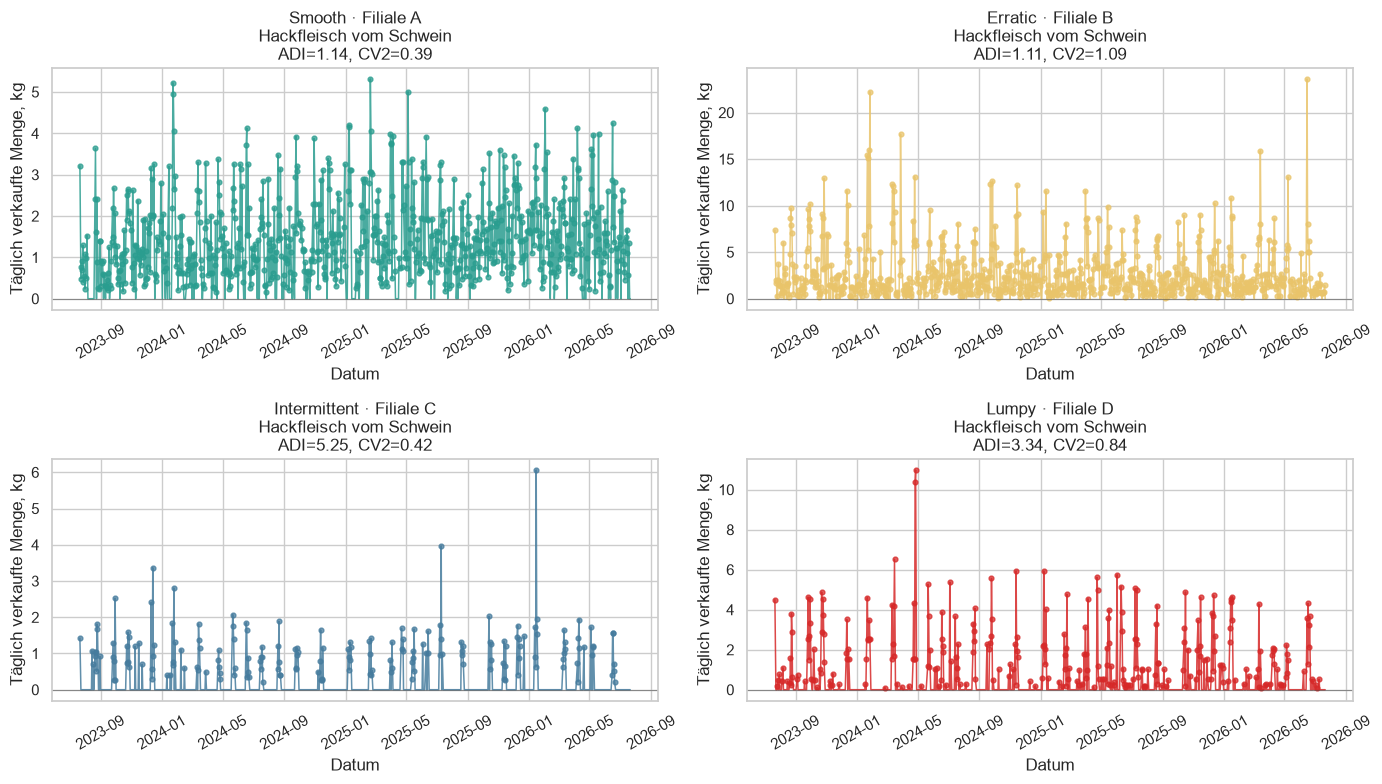

In [21]:
daily_example_keys = daily_example_series[
    ["demand_class", "store_label", "ARTIKEL_ID", "MARKT_ID"]
].copy()
con.register("daily_example_keys", daily_example_keys)

daily_examples_query = f"""
SELECT
    k.demand_class,
    k.store_label,
    d.ARTIKEL_ID,
    d.MARKT_ID,
    CAST(d.DATE AS DATE) AS sale_date,
    SUM(CAST(COALESCE(d.{DEMAND_COL}, 0) AS DOUBLE)) AS demand
FROM read_parquet(?) AS d
JOIN daily_example_keys AS k
    ON d.ARTIKEL_ID = k.ARTIKEL_ID
    AND d.MARKT_ID = k.MARKT_ID
WHERE d.is_active
GROUP BY
    k.demand_class, k.store_label, d.ARTIKEL_ID, d.MARKT_ID, sale_date
ORDER BY k.demand_class, k.store_label, sale_date
"""
daily_example_ts = con.execute(
    daily_examples_query, [daily_glob]
).fetchdf()

daily_plot_data = daily_example_ts.merge(
    daily_example_series[[
        "demand_class", "store_label", "ARTIKEL_ID", "MARKT_ID",
        "ARTIKEL_BEZ", "ARTIKEL_INHALT", "VERKAUFSEINHEIT",
        "ADI", "CV2", "active_days", "demand_days",
    ]],
    on=["demand_class", "store_label", "ARTIKEL_ID", "MARKT_ID"],
    how="left",
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)
axes = axes.ravel()

for ax, demand_class in zip(axes, CLASS_ORDER):
    subset = daily_plot_data[
        daily_plot_data["demand_class"].eq(demand_class)
    ].sort_values("sale_date")
    if subset.empty:
        ax.axis("off")
        ax.set_title(f"{demand_class.capitalize()}\nKeine Daten")
        continue

    meta = subset.iloc[0]
    color = CLASS_PALETTE[demand_class]
    positive_subset = subset[subset["demand"] > 0]
    article_name = str(meta["ARTIKEL_BEZ"])
    if len(article_name) > 44:
        article_name = article_name[:41] + "..."

    ax.plot(subset["sale_date"], subset["demand"], color=color, linewidth=1.1, alpha=0.85)
    ax.scatter(
        positive_subset["sale_date"], positive_subset["demand"],
        color=color, s=12, alpha=0.75,
    )
    ax.axhline(0, color="#444444", linewidth=0.8, alpha=0.5)
    ax.set_title(
        f"{demand_class.capitalize()} · {meta['store_label']}\n"
        f"{article_name}\n"
        f"ADI={meta['ADI']:.2f}, CV2={meta['CV2']:.2f}"
    )
    ax.set_xlabel("Datum")
    ax.set_ylabel(f"Täglich verkaufte Menge, kg")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()


## Interpretation

Die tägliche Aggregation macht sichtbar, wie unterschiedlich Produkt-Filial-Abverkaufsreihen auch innerhalb derselben Datenbasis ausfallen. `Smooth` und `erratic` stehen für häufige Abverkaufstage, während `intermittent` und `lumpy` stärkere Lücken zwischen Verkäufen zeigen.

Hohe Null-Abverkaufsanteile erhöhen den ADI und verschieben Reihen in seltenere Klassen. Deshalb ist die tägliche Klassifikation besonders empfindlich gegenüber langen Abschnitten ohne Verkäufe.
